In [84]:
from tara_preprocessing import get_just_ecog_data,get_electrode_normalized_loc,car
from noah_production_funcs import single_patient_prediction_pure,create_lapaican_rbf,create_lapaican_knn
from tara_preprocessing import remove_duplicates, hold_out, preprocessing,apply_car_function,clip_time_series
from tara_preprocessing import make_patient_correlation_matrix
from noah_production_funcs import create_u
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
import geoopt
import tqdm

## Notes for futre me:

Here is the list of clipped patient dimensions:
(256000, 46)
(256000, 41)
(256000, 50)
(256000, 31)
(256000, 52)
(251240, 39)
(256000, 60)
(256000, 56)
(256000, 102)
(256000, 58)
(256000, 42)
(180920, 40)
(256000, 39)
(256000, 58)

for some reason, some are shorter in the time dimension 

In [114]:
data_root = Path("/Users/noahwanless/Desktop/Spring2026/M467/faces_basic/data")
registered_dir = Path("../SuperEeg-M467-project/registered_outputs")
ecogs = get_just_ecog_data(registered_dir,data_root)
xyz = get_electrode_normalized_loc(registered_dir)
print('Downloaded data')
ecogs = clip_time_series(ecogs)
print("Time series clipped")
ecogs_no_dups,xyz_no_dups = remove_duplicates(ecogs,xyz)
print('Removed duplicate electrodes')
xyz_clea, cleane = preprocessing(ecogs_no_dups,xyz_no_dups,notch_size=.05)
print("Done Preprocessing")
cleaned_f,xyz_f,fake_pat_beginning = hold_out(xyz_clea,cleane,0,[40,41])
cleaned_f = apply_car_function(cleaned_f,0)
print("Done holding out electrodes")


[PosixPath('../SuperEeg-M467-project/registered_outputs/aa_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ap_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ca_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/de_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/fp_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ha_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ja_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jm_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jt_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/mv_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/rn_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_output

In [115]:
patient_corr_mat = make_patient_correlation_matrix(xyz_f,cleaned_f)
print('Got Correlation Matrices, done!')
#U_det, loss = create_u(k=40,r=500,lamb=0.001,patient_corr_mat=patient_corr_mat,xyz_clean=xyz_f,training_steps=800,graph='rbf') #.0005

Got Correlation Matrices, done!


In [87]:
def project_diag(K):
    K.fill_diagonal_(1)
    #np.fill_diagonal(K, 1) #works in place
    return K

def project_psd(K):
    K_temp = (K + K.T) / 2
    eigenvalues,eigenvectors = np.linalg.eigh(K_temp)
    D = torch.zeros(K.shape)
    new_eigen  = []
    for val in eigenvalues:
        if val > 0:
            new_eigen.append(val)
        else:
            #print('found a eignevalue less then zero')
            new_eigen.append(0)
    
    new_e = torch.tensor(new_eigen, dtype=torch.float32)
    D.diagonal().copy_(new_e)
    Q = eigenvectors
    return Q@D@Q.T


In [124]:
# This is the objective function defined by Javier, so if you have any questions go to him first
def object_func_3(C,K,L,lamb,patient_node_num,num_pat):
    sum = torch.zeros(1,requires_grad=True) 
    iter = 0
    for i in range(num_pat):
        c = C[i] #each patient correlation matrix
        num_nodes = patient_node_num[i]
        k = K[iter:iter+num_nodes,iter:iter+num_nodes]
        sum = sum + (torch.linalg.norm((k - c),ord='fro'))**2 
        iter = iter + num_nodes
    sum = sum + lamb*torch.trace(K.T@L@K)
    return sum

############## reate_u ################ creates the U matrix
# r: the 'complexity' of our approximation (the number of columns of our U matrix we will make)
# k: 
#       the number of nearest neighbors a electrode is 'connected to' if graph='knn'
#       the scaler for the rbf function if graph='rbf'
# lamb: the parameter on trace aspect of the loss function
# xyz_clean: normalized electrode locations on the brain
# patient_corr_mat: the list of indivdual patient correlation matrices (ONLY containing the nodes they obsevered on them)
# object_func: the objective function we want to minimize
# training_steps: number of steps to train the function (usually 500 should be enough, defaults to 1000)
# lr: learning rate of the optimizer
# graph: 'knn' or 'rbf' defines what graph set up to use for making the laplacian
######### Returns #########
# U: this is the big U matrix, to get our correlation matrix do U@U.T 
# Loss: this is the list of loss at each step of training to ensure that the function is converging
######### Notes: #########
# It must be noted that yes, to our knowlegde the constrained of the manifold is applied to the rows of the 
# matrix U. as is desired by the formula
# This is checked by both a test of the output of the model (which gives a matrix were only the rows are norm 1)
# and by examining the source code of the geoopt.optim.RiemannianAdam().step() function, which shows it iterates through the 
# entires U (the only param 'group' we gave) which means iterating through the rows, and those are what is constrained to the 
# manifold
# For more consult the following sites:
# https://geoopt.readthedocs.io/en/latest/_modules/geoopt/optim/radam.html#RiemannianAdam
# https://github.com/pytorch/pytorch/blob/v2.10.0/torch/optim/optimizer.py#L342
##############################
def create_k(k,lamb,patient_corr_mat,xyz_clean,training_steps=1000,lr=0.01,graph='knn',K_proj_iter = 20):
    ############## Make Graph ##############
    num_nodes = xyz_clean.shape[0]
    if graph == 'knn':
        Glaplacian = create_lapaican_knn(xyz_clean,k)
    elif graph == 'rbf':
        Glaplacian = create_lapaican_rbf(xyz_clean,k)
    ############## Preparing function inputs ##############
    L = torch.tensor(Glaplacian,dtype=torch.float32,requires_grad=False)
    patient_node_num = [] #number of electrodes each patient has
    C = []
    for corr in patient_corr_mat:
        C.append(torch.tensor(np.array(corr),requires_grad=True))
        patient_node_num.append(corr.shape[0])
    ############## Preparing K and its manifold ##############
    rng = np.random.default_rng()
    K = torch.rand((num_nodes,num_nodes),dtype=torch.float32,requires_grad=True)
    #print(K.shape)
    ############## Training U ##############
    optimizer = torch.optim.Adam([K],lr=0.001)
    loss_list = []
    num_pat = len(patient_corr_mat) #gets the number of patients
    print("Optimizing U")
    for step in (range(training_steps)): #tqdm
        optimizer.zero_grad()
        z = object_func_3(C,K,L,lamb,patient_node_num,num_pat) #this is our loss function
        #print(z.grad_fn.next_functions)
        loss_list.append(z.detach())
        z.backward()
        optimizer.step()
        #K_ref = K.detach()
        #with torch.no_grad():
            #for _ in range(K_proj_iter):
                #K.data = project_diag(K)
                #K.data = project_psd(K)
            #print((K_ref-K).mean()) #or how much has K changed
        #print(z.detach().mean())    
            #K = K_det
    return K.detach(),loss_list


It seems that after a few iterations the loss stagnates and doesnt change, or at least that what it seems to do

When looking at the mean change across the entire matrix K, it seems that the changes become almost 0

look at the top few:

torch.Size([566, 566])
Optimizing U
tensor(0.0081)
tensor(2.1486e-05)
tensor(7.5322e-08)
tensor(-2.4541e-10)
tensor(-1.4512e-10)
tensor(-1.3573e-10)
tensor(-2.4950e-10)
tensor(-1.1387e-10)
tensor(-1.3517e-10)
tensor(-1.0010e-10)


it seems to be this way because the auto grad is destroyed after the first step: here is the list of gradient notes along with the one before it, see how its all nones after the first time, this means that the projections are killing the thingy

Optimizing U
((<AddBackward0 object at 0x17a504d30>, 0), (<MulBackward0 object at 0x17a3f9ab0>, 0))
((<AddBackward0 object at 0x17a504c40>, 0), (None, 0))
((<AddBackward0 object at 0x17a504c40>, 0), (None, 0))
((<AddBackward0 object at 0x17a504c40>, 0), (None, 0))

In [127]:
K,loss = create_k(k=20,lamb=0,patient_corr_mat=patient_corr_mat,xyz_clean=xyz_f,training_steps=1000,lr=0.01,graph='knn',K_proj_iter = 20)

Optimizing U


In [94]:
K

tensor([[1.0000, 0.2234, 0.1358,  ..., 0.0708, 0.0723, 0.0713],
        [0.2234, 1.0000, 0.1737,  ..., 0.0740, 0.0739, 0.0727],
        [0.1358, 0.1737, 1.0000,  ..., 0.0755, 0.0754, 0.0748],
        ...,
        [0.0708, 0.0740, 0.0755,  ..., 1.0000, 0.2323, 0.1619],
        [0.0723, 0.0739, 0.0754,  ..., 0.2323, 1.0000, 0.2473],
        [0.0713, 0.0727, 0.0748,  ..., 0.1619, 0.2473, 1.0000]])

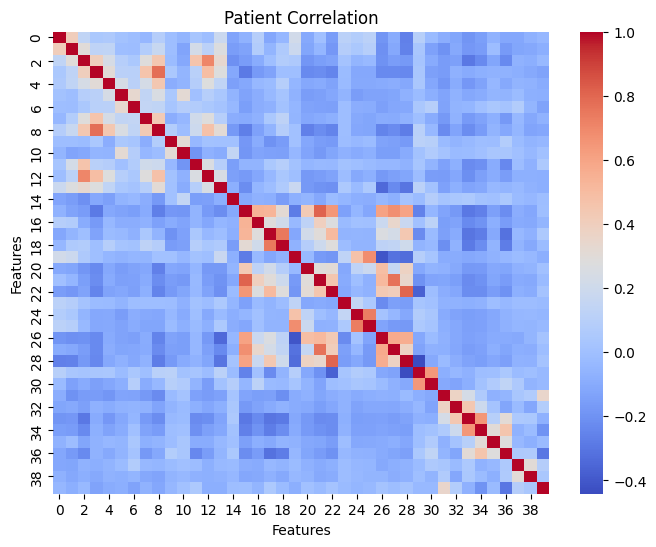

In [129]:
plt.figure(figsize=(8, 6))
sns.heatmap(patient_corr_mat[0], cmap='coolwarm')  #[44:84,44:84]-patient_corr_mat[1].to_numpy()
plt.title('Patient Correlation')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

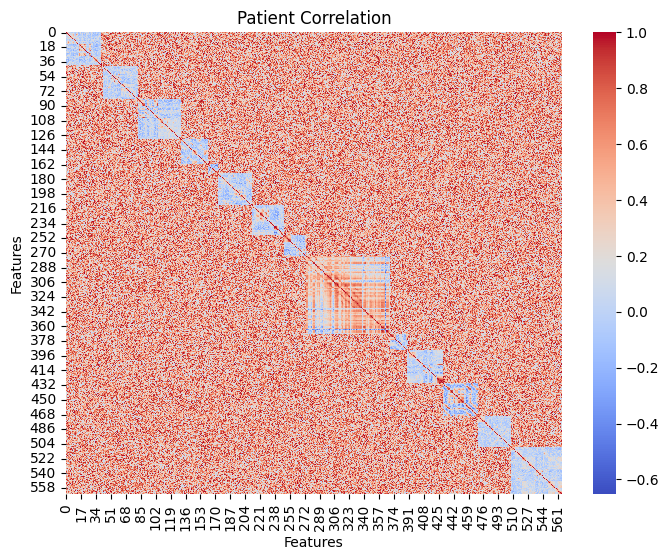

In [128]:
plt.figure(figsize=(8, 6))
sns.heatmap(K, cmap='coolwarm')  #[44:84,44:84]-patient_corr_mat[1].to_numpy()
plt.title('Patient Correlation')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

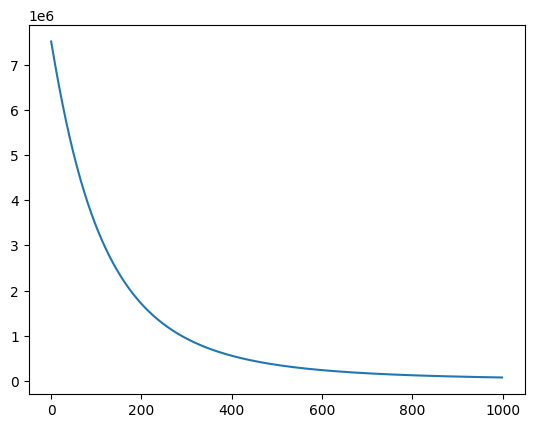

In [119]:
plt.plot(loss)

In [ ]:
pred,indices = single_patient_prediction_pure(0,cleaned_f,(U_det@U_det.T))
held = cleaned_f[1][:,0]
print(cleaned_f[1].shape)
print(held.shape)
row_means = np.mean(held, axis=0, keepdims=True)
row_stds = np.std(held, axis=0, keepdims=True)
held_z_score = (held - row_means) / row_stds

In [ ]:
plt.figure(figsize=(16, 7))
plt.plot(pred[100000:100500,0],label='pred')
plt.plot(held_z_score[100000:100500],label='true_z_score')
plt.legend()

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(U_det@U_det.T, cmap='coolwarm')  #[44:84,44:84]-patient_corr_mat[1].to_numpy()
plt.title('Patient Correlation')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()